# PCArot - autos2006 dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## autos2006 dataset

In [2]:
# autos2006 dataset
from scientisttools.datasets import autos2006
autos2006._fields

('actif', 'ind_sup', 'sup_var', 'data')

In [3]:
# overall dataset
data = autos2006.data
data.info()

<class 'pandas.DataFrame'>
Index: 20 entries, Alfasud TI to Peugeot 304 S
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CYL        20 non-null     int64  
 1   PUISS      20 non-null     int64  
 2   LONG       20 non-null     int64  
 3   LARG       20 non-null     int64  
 4   POIDS      20 non-null     int64  
 5   VMAX       20 non-null     int64  
 6   PRIX       18 non-null     float64
 7   RPOIDPUIS  18 non-null     float64
 8   FINITION   18 non-null     str    
dtypes: float64(2), int64(6), str(1)
memory usage: 1.6+ KB


## Instanciation & training `PCA`

In [4]:
#instanciation & training PCA
from scientisttools import PCA
clf1 = PCA(ncp=2,ind_sup=(18,19),sup_var=(6,7,8))
clf1.fit(data)

,ncp,2
,ind_sup,"(18, ...)"
,sup_var,"(6, ...)"
,scale_unit,True
,iv,None
,ortho,False
,partial,None
,group,None
,option,'between'
,row_w,None
,col_w,None


### Eigen values

In [5]:
#eigen values
from scientisttools import get_eig
eig = get_eig(clf1)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%)
Dim1,4.420858,3.564796,73.680968,73.680968
Dim2,0.856062,0.482996,14.267705,87.948672
Dim3,0.373066,0.159144,6.217768,94.166440
Dim4,0.213922,0.121121,3.565368,97.731809
Dim5,0.092801,0.049511,1.546687,99.278495
Dim6,0.043290,NaN,0.721505,100.000000


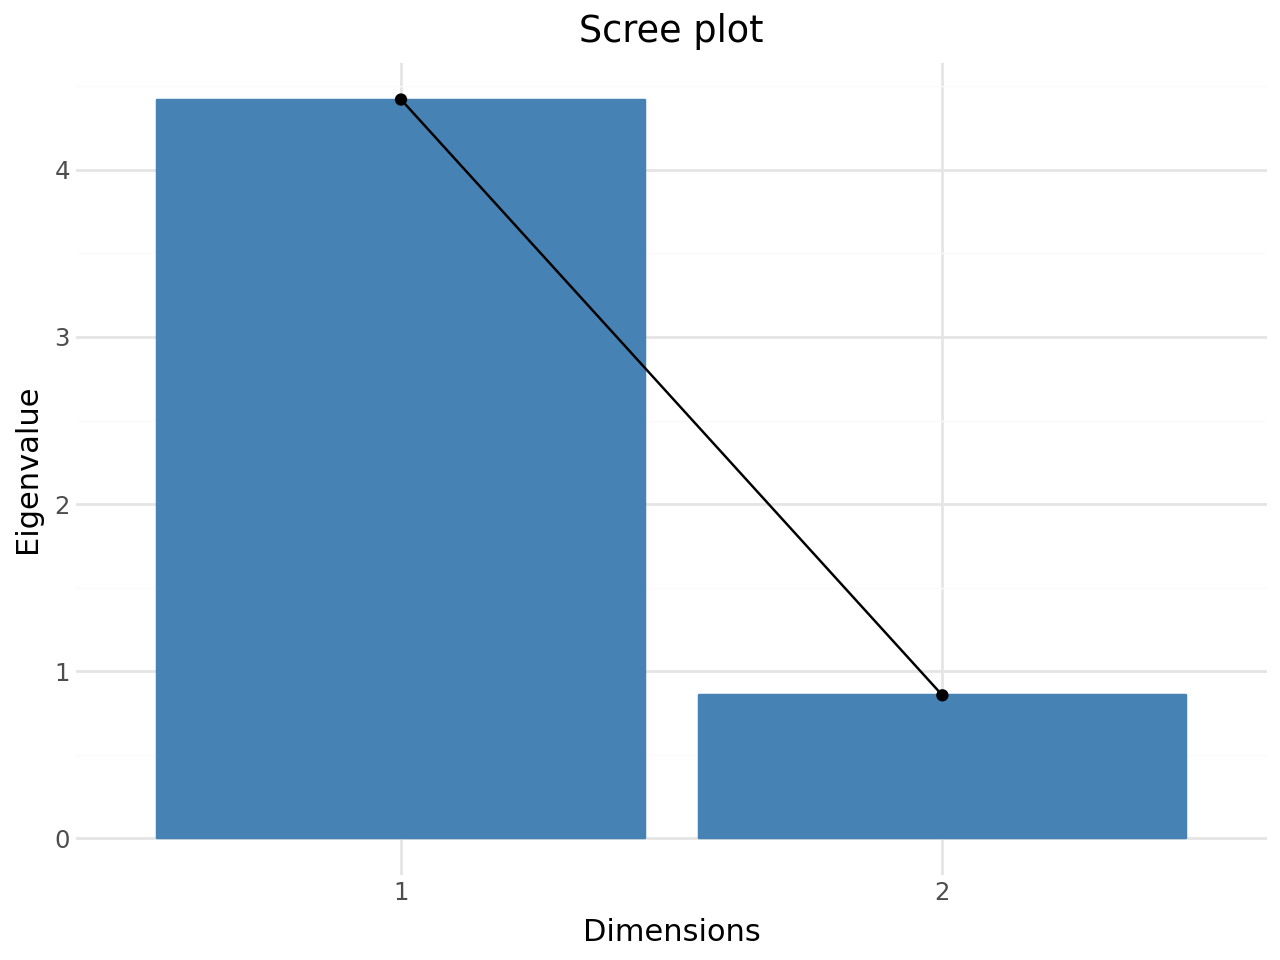

None


In [6]:
# scree plot
from scientisttools import fviz_screeplot
p = fviz_screeplot(clf1,choice="eigenvalue")
print(p.show())

### Variables informations

In [7]:
# variables informations
from scientisttools import get_pca
var = get_pca(clf1,"var")
var._fields

('coord', 'cos2', 'contrib', 'infos')

#### Variables coordinates

In [8]:
# variables coordinates
var.coord

,Dim1,Dim2
CYL,0.893464,0.114906
PUISS,0.886858,0.384689
LONG,0.886155,-0.381029
LARG,0.813536,-0.412736
POIDS,0.905187,-0.224532
VMAX,0.754710,0.573519


#### Variables contributions

In [9]:
# variables contributions
var.contrib

,Dim1,Dim2
CYL,18.057062,1.542342
PUISS,17.791052,17.286793
LONG,17.762847,16.959384
LARG,14.970882,19.899361
POIDS,18.534057,5.889155
VMAX,12.884099,38.422964


#### Variables cos2

In [10]:
# variables cos2
var.cos2

,Dim1,Dim2
CYL,0.798277,0.013203
PUISS,0.786517,0.147986
LONG,0.785270,0.145183
LARG,0.661841,0.170351
POIDS,0.819364,0.050415
VMAX,0.569588,0.328925


### Individuals informations

In [11]:
# individuals informations
ind = get_pca(clf1,"ind")
ind._fields

('coord', 'cos2', 'contrib', 'infos')

#### Individuals coordinates

In [12]:
# individuals coordinates
ind.coord

,Dim1,Dim2
Alfasud TI,-2.138924,1.785681
Audi 100,1.561459,-1.527040
Simca 1300,-1.119385,-0.674505
Citroen GS Club,-2.573742,0.112884
Fiat 132,0.427855,0.695567
Lancia Beta,-0.304238,-0.196149
Peugeot 504,0.683928,-0.933057
Renault 16 TL,-1.948493,-0.980448
Renault 30,4.409735,1.063633
Toyota Corolla,-3.985782,0.236240


## Varimax rotation in PCA

In [13]:
# varimax rotation in PCA
from scientisttools import PCArot
clf2 = PCArot(ncp=2)

### `fit` function

In [14]:
#fit function
clf2.fit(clf1)

,ncp,2
,normalize,True
,max_iter,1000
,tol,1e-05
Name,Type,Value
call_,call,"call(Xtot= ...ar=(6, 7, 8)))"
eig_,DataFrame,Eigenva... 87.948672
ind_,ind,ind(coord= ...555 -1.888901)
ind_sup_,ind_sup,ind_sup(coord...880 -0.506540)
levels_sup_,levels_sup,levels_sup(co...900 1.675634)
quali_var_sup_,quali_var_sup,quali_var_sup...671 0.321542)


### `fit_transform` function

In [15]:
#fit_transform function - individuals coordinates after rotation
ind_coord_rot = clf2.fit_transform(clf1)
ind_coord_rot

,Dim1,Dim2
Alfasud TI,-2.785675,-0.060545
Audi 100,2.180501,-0.124184
Simca 1300,-0.400083,-1.244152
Citroen GS Club,-2.013631,-1.606916
Fiat 132,-0.134860,0.805411
Lancia Beta,-0.100307,-0.347812
Peugeot 504,1.128760,-0.253482
Renault 16 TL,-0.823723,-2.019748
Renault 30,2.623685,3.700453
Toyota Corolla,-3.158757,-2.442238


### `transform` function

In [16]:
# transform function - individuals coordinates after rotation
ind_coord = clf2.transform(clf1.ind_.coord)
ind_coord

,Dim1,Dim2
Alfasud TI,-2.785675,-0.060545
Audi 100,2.180501,-0.124184
Simca 1300,-0.400083,-1.244152
Citroen GS Club,-2.013631,-1.606916
Fiat 132,-0.134860,0.805411
Lancia Beta,-0.100307,-0.347812
Peugeot 504,1.128760,-0.253482
Renault 16 TL,-0.823723,-2.019748
Renault 30,2.623685,3.700453
Toyota Corolla,-3.158757,-2.442238


### Eigen values after rotation

In [17]:
# eigen values after rotation
eig_rot = get_eig(clf2)
eig_rot

,Eigenvalue,Proportion (%),Cumulative (%)
Dim1,2.880241,48.004019,48.004019
Dim2,2.396679,39.944654,87.948672


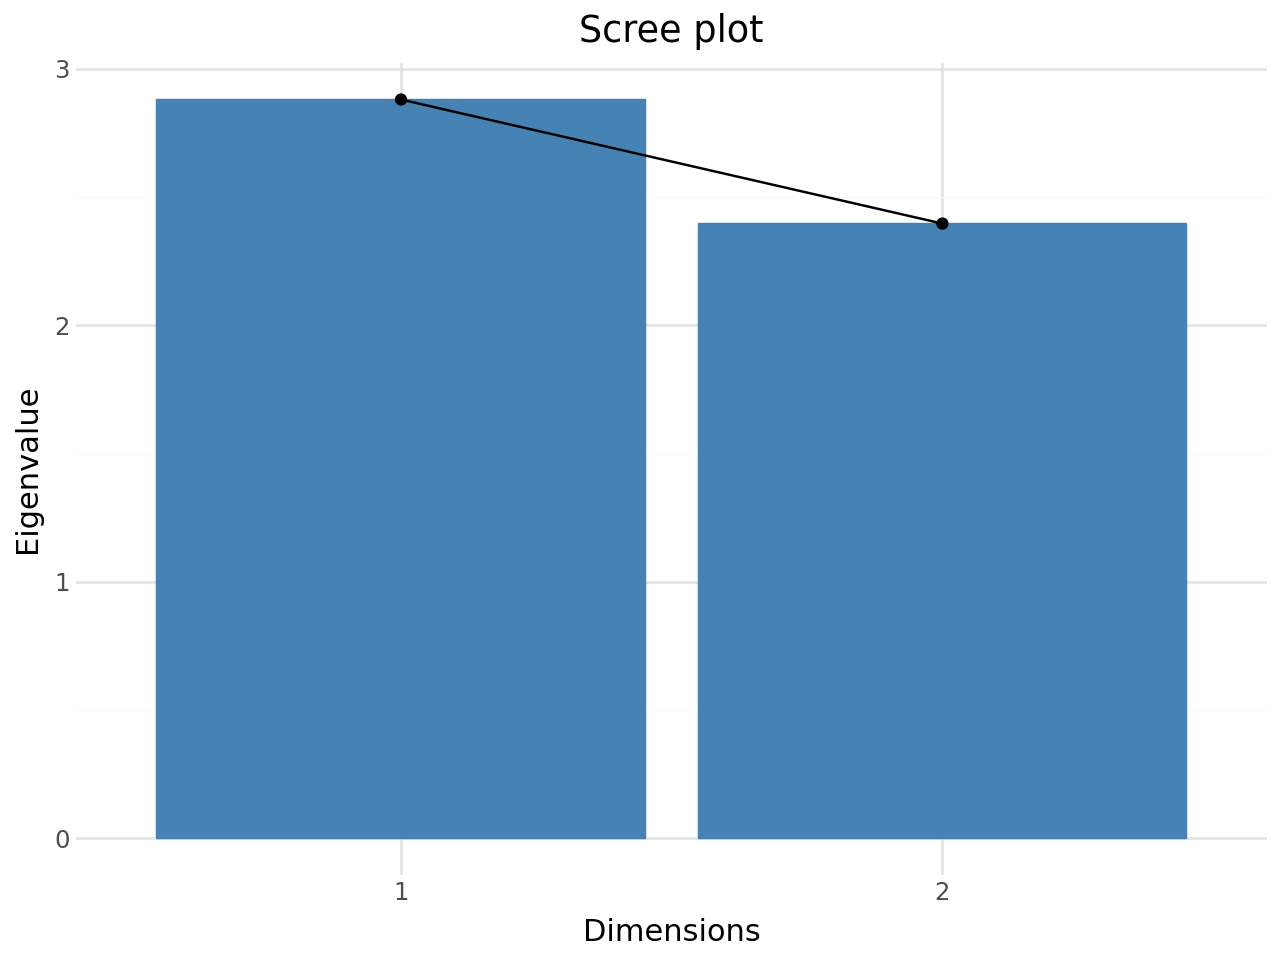

None


In [18]:
# scree plot
p = fviz_screeplot(clf2,choice="eigenvalue")
print(p.show())

### Variables informations after rotation

In [19]:
# variables informations after rotation
var_rot = get_pca(clf2,"var")
var_rot._fields

('coord',)

#### Variables coordinates after rotation

In [20]:
#variables coordinates after rotation
var_rot.coord

,Dim1,Dim2
CYL,0.597722,0.673950
PUISS,0.415389,0.872900
LONG,0.918243,0.295438
LARG,0.884366,0.223806
POIDS,0.829704,0.425876
VMAX,0.191674,0.928318


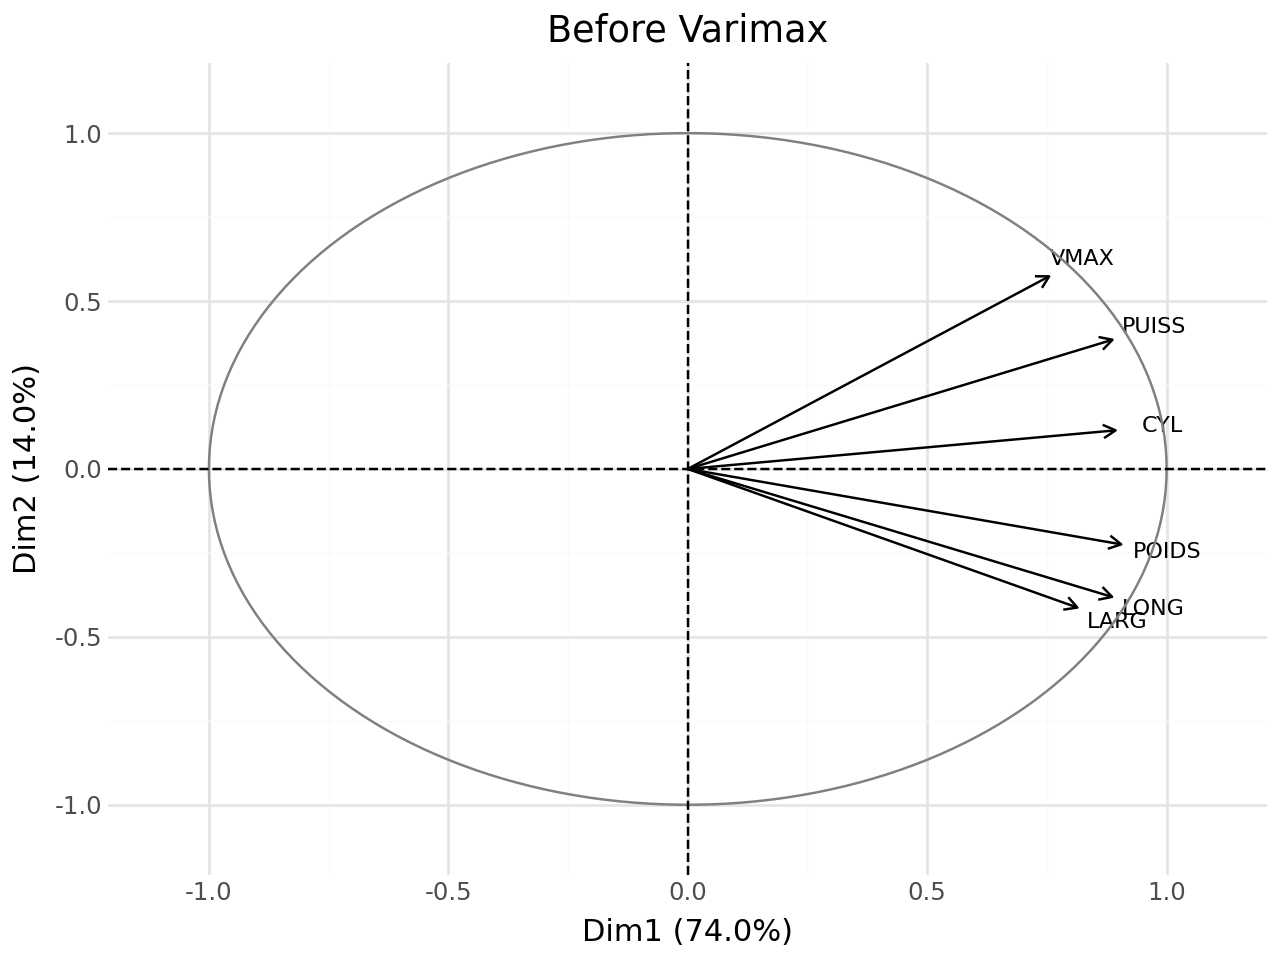

None


In [21]:
# graph of variables - before varimax rotation
from scientisttools import fviz_pca
p = fviz_pca(
    obj=clf1,
    choice="var",
    repel=True,
    title = "Before Varimax",
    quanti_sup=False
)
print(p.show())

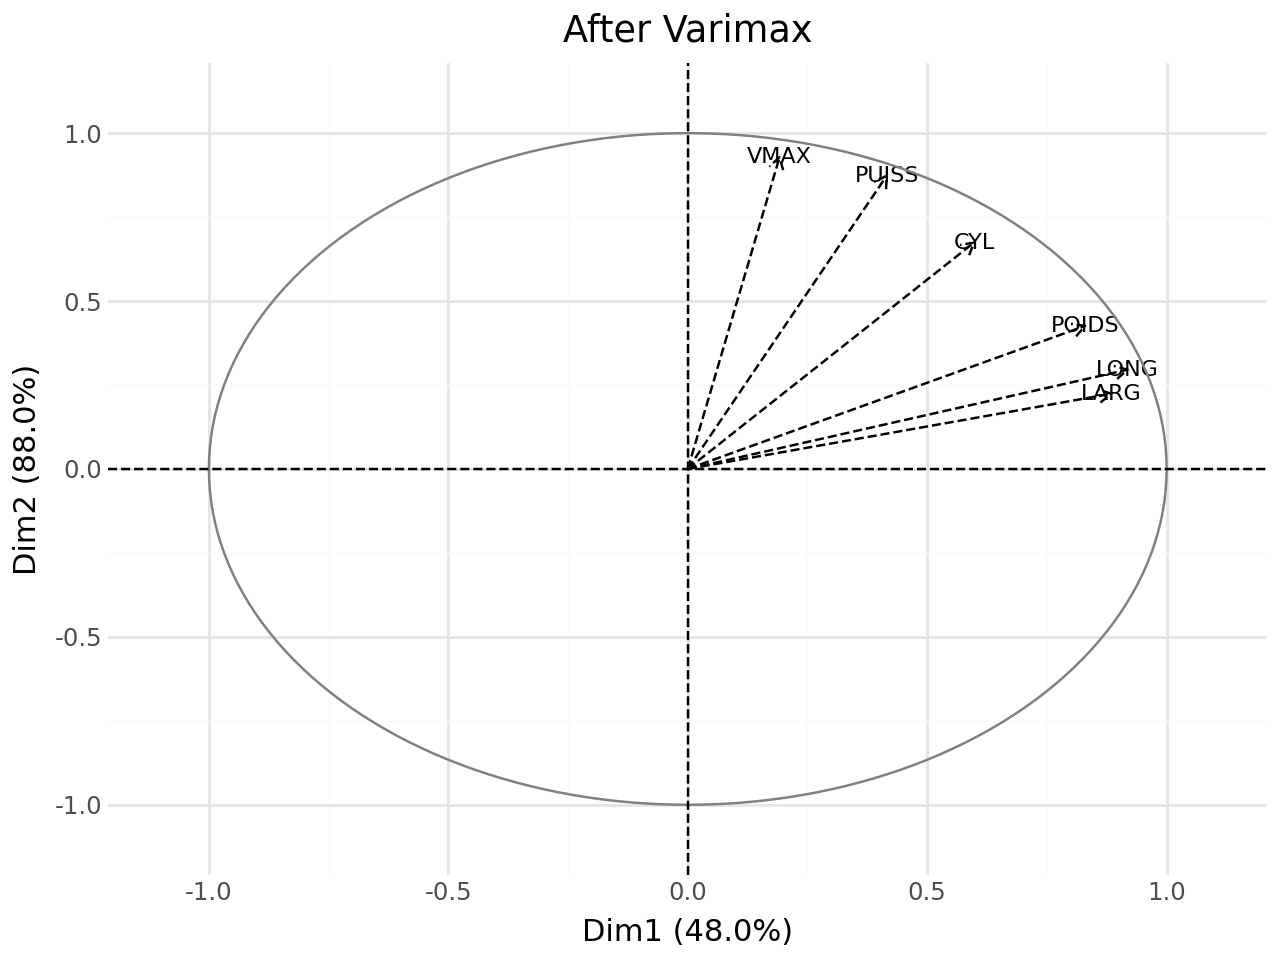

None


In [22]:
# graph of variables - after varimax rotation
from plotnine import ggplot
from scientisttools import fviz_circle, add_arrow, set_axis
p = add_arrow(
    p = ggplot(),
    data = var_rot.coord,
    color="black"
)
p = fviz_circle(p=p)
# set axis
p = set_axis(
    p = p,
    obj=clf2,
    title = "After Varimax",
    x_lim = (-1.1,1.1),
    y_lim = (-1.1,1.1)
)
print(p.show())

### Individuals informations after rotation

In [23]:
# individuals informations after rotation
ind_rot = get_pca(clf2,"ind")
ind_rot._fields

('coord',)

#### Individuals coordinates after rotation

In [24]:
# individuals coordinates after rotation
ind_rot.coord

,Dim1,Dim2
Alfasud TI,-2.785675,-0.060545
Audi 100,2.180501,-0.124184
Simca 1300,-0.400083,-1.244152
Citroen GS Club,-2.013631,-1.606916
Fiat 132,-0.134860,0.805411
Lancia Beta,-0.100307,-0.347812
Peugeot 504,1.128760,-0.253482
Renault 16 TL,-0.823723,-2.019748
Renault 30,2.623685,3.700453
Toyota Corolla,-3.158757,-2.442238


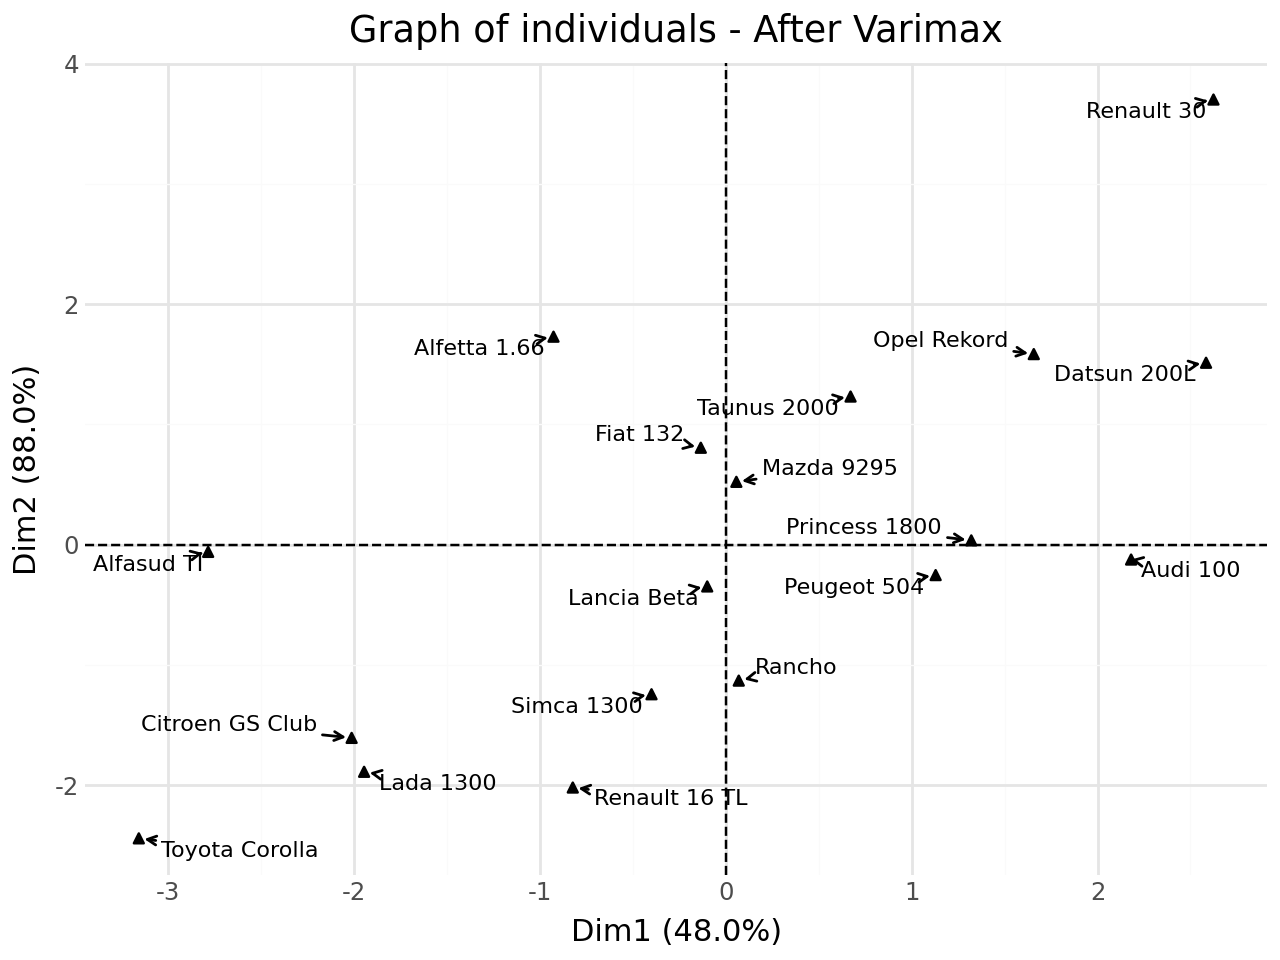

None


In [25]:
# graph of individuals after rotation
from scientisttools import add_scatter
p = add_scatter(
    p = ggplot(),
    data = ind_rot.coord,
    color="black",
    repel = True
)
# set axis
p = set_axis(
    p = p,
    obj=clf2,
    title = "Graph of individuals - After Varimax"
)
print(p.show())

## Statistics in PCArot

In [26]:
# statistics in PCArot
from scientisttools import statsPCArot
stats = statsPCArot(clf2)
stats._fields

('corr', 'others')

### Correlation

In [27]:
# correlation
corr = stats.corr
corr._fields

('corrcoef', 'pcorrcoef', 'reconst', 'resid')

#### Pearson correlation

In [28]:
# pearson correlation
corr.corrcoef

,CYL,PUISS,LONG,LARG,POIDS,VMAX
CYL,1.000000,0.796628,0.701462,0.629757,0.788952,0.664934
PUISS,0.796628,1.000000,0.641362,0.520832,0.765293,0.844379
LONG,0.701462,0.641362,1.000000,0.849266,0.868090,0.475928
LARG,0.629757,0.520832,0.849266,1.000000,0.716874,0.472945
POIDS,0.788952,0.765293,0.868090,0.716874,1.000000,0.477596
VMAX,0.664934,0.844379,0.475928,0.472945,0.477596,1.000000


#### Partial correlation 

In [29]:
# partial correlation
corr.pcorrcoef

,CYL,PUISS,LONG,LARG,POIDS,VMAX
CYL,1.000000,0.107081,-0.059944,0.109058,0.320078,0.189489
PUISS,0.107081,1.000000,-0.083218,-0.334079,0.652087,0.841449
LONG,-0.059944,-0.083218,1.000000,0.581624,0.529678,0.090026
LARG,0.109058,-0.334079,0.581624,1.000000,0.126883,0.330532
POIDS,0.320078,0.652087,0.529678,0.126883,1.000000,-0.610662
VMAX,0.189489,0.841449,0.090026,0.330532,-0.610662,1.000000


#### Reconst correlation

In [30]:
# reconst correlation
corr.reconst

,CYL,PUISS,LONG,LARG,POIDS,VMAX
CYL,0.811481,0.836578,0.747964,0.679439,0.782952,0.740207
PUISS,0.836578,0.934503,0.639316,0.562716,0.716398,0.889948
LONG,0.747964,0.639316,0.930453,0.878183,0.887690,0.450263
LARG,0.679439,0.562716,0.878183,0.832192,0.829076,0.377272
POIDS,0.782952,0.716398,0.887690,0.829076,0.869779,0.554381
VMAX,0.740207,0.889948,0.450263,0.377272,0.554381,0.898512


#### Resid correlation

In [31]:
# resid correlation
corr.resid

,CYL,PUISS,LONG,LARG,POIDS,VMAX
CYL,NaN,-0.039951,-0.046503,-0.049682,0.006000,-0.075273
PUISS,-0.039951,NaN,0.002046,-0.041884,0.048895,-0.045568
LONG,-0.046503,0.002046,NaN,-0.028917,-0.019599,0.025666
LARG,-0.049682,-0.041884,-0.028917,NaN,-0.112202,0.095673
POIDS,0.006000,0.048895,-0.019599,-0.112202,NaN,-0.076785
VMAX,-0.075273,-0.045568,0.025666,0.095673,-0.076785,NaN


### Others statistics

In [32]:
# others statistics
others = stats.others
others._fields

('vaccounted', 'explained_variance')

#### Variance accounted

In [33]:
# variance accounted
others.vaccounted.T

,Eigenvalue,SS loadings,Proportion Var,Cumulative Var,Proportion Explained,Cumulative Proportion
Dim1,4.420858,2.880241,48.004019,48.004019,54.581857,54.581857
Dim2,0.856062,2.396679,39.944654,87.948672,45.418143,100.000000


#### Explained variance

In [34]:
# explained variance
others.explained_variance

,Weighted,Unweighted,R2
Dim1,4.420858,2.880241,1.0
Dim2,0.856062,2.396679,1.0


## Supplementary individuals informations after rotation

In [35]:
# supplementary individuals informations after rotation
ind_sup_rot = clf2.ind_sup_
ind_sup_rot._fields

('coord',)

### Supplementary individuals coordinates after rotation

In [36]:
# supplementary individuals coordinates after rotation
ind_sup_rot.coord

,Dim1,Dim2
Peugeot 604,3.969569,3.912467
Peugeot 304 S,-2.493880,-0.506540


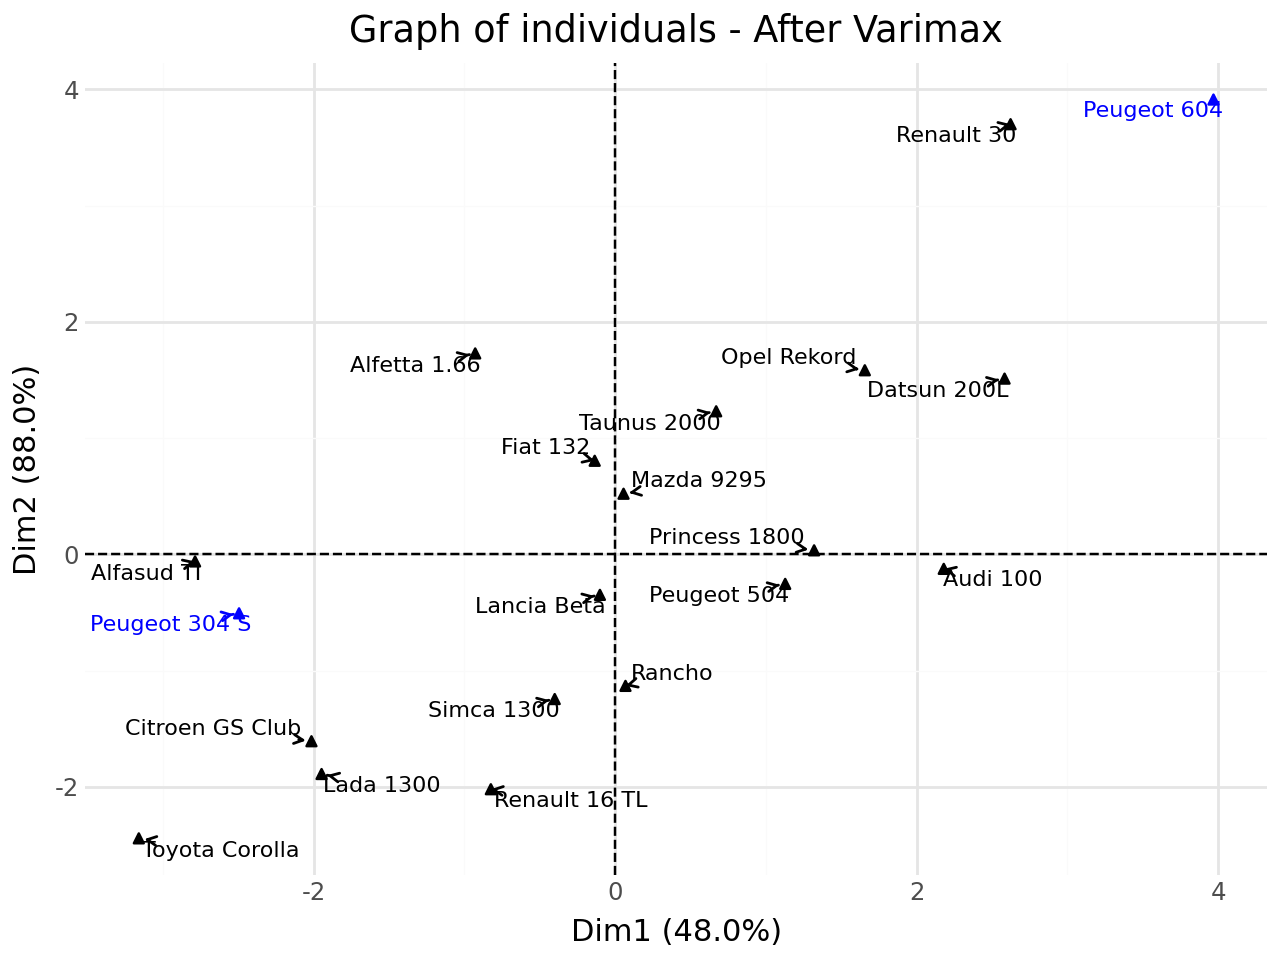

None


In [37]:
# graph of individuals with supplementary individuals
from scientisttools import add_scatter
p = add_scatter(
    p = ggplot(),
    data = ind_rot.coord,
    color="black",
    repel = True
)
# add 
p = add_scatter(
    p = p,
    data = ind_sup_rot.coord,
    color="blue",
    repel = True
)
# set axis
p = set_axis(
    p = p,
    obj=clf2,
    title = "Graph of individuals - After Varimax"
)
print(p.show())

## Supplementary quantitative variables informations after rotation

In [38]:
# supplementary quantitative variables informations after rotation
quanti_var_sup_rot = clf2.quanti_var_sup_
quanti_var_sup_rot._fields

('coord',)

### Supplementary quantitative variables coordinates after rotation

In [39]:
# Supplementary quantitative variables coordinates after rotation
quanti_var_sup_rot.coord

,Dim1,Dim2
PRIX,0.525090,0.573164
RPOIDPUIS,-0.001734,-0.894025


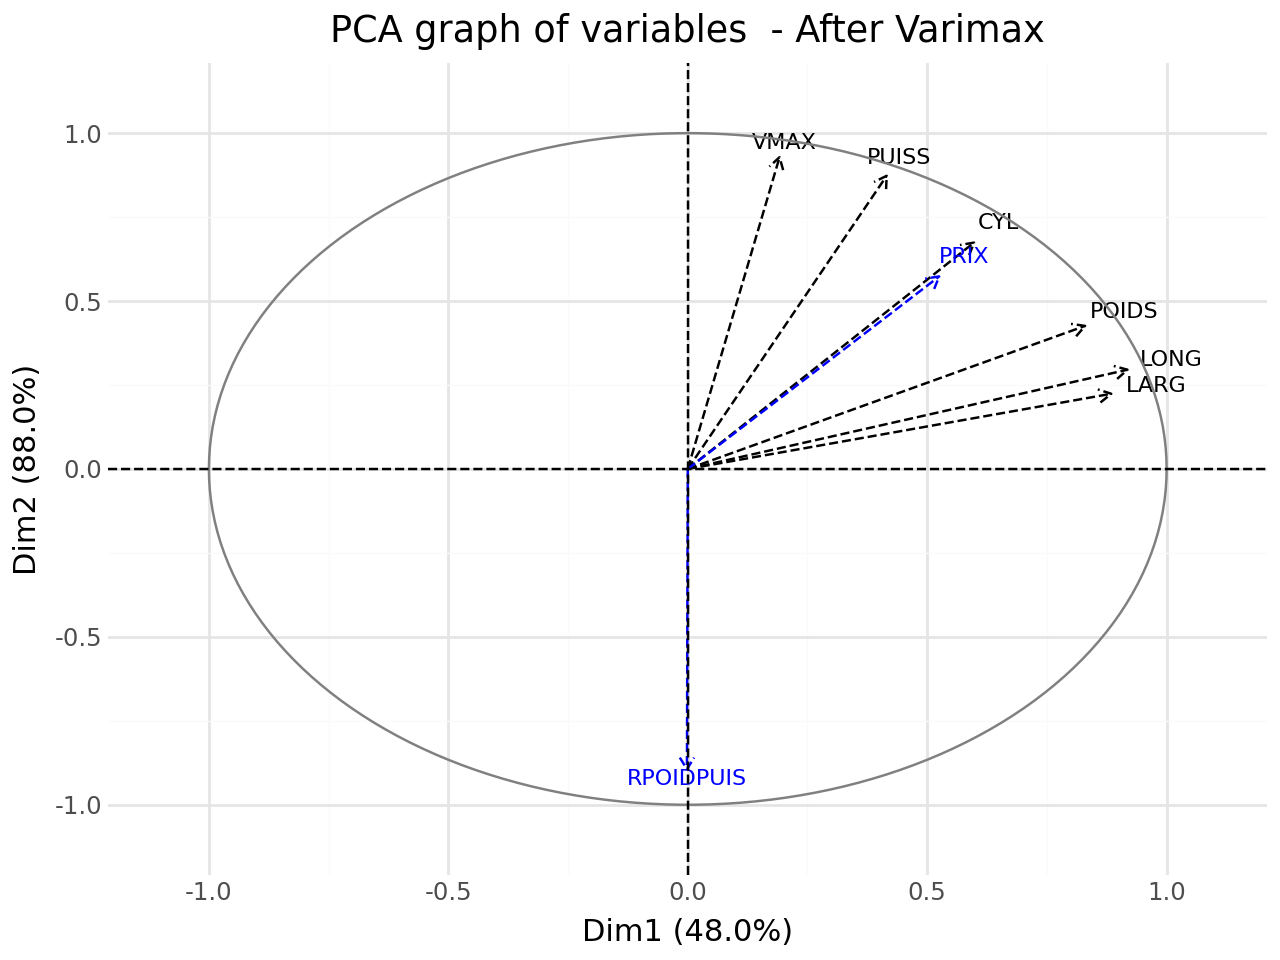

None


In [40]:
# graph of variables - after varimax rotation
p = add_arrow(
    p = ggplot(),
    data = var_rot.coord,
    color="black",
    repel=True
)
p = add_arrow(
    p = p,
    data = quanti_var_sup_rot.coord,
    color="blue",
    repel = True
)
p = fviz_circle(p=p)
# set axis
p = set_axis(
    p = p,
    obj=clf2,
    title = "PCA graph of variables  - After Varimax",
    x_lim = (-1.1,1.1),
    y_lim = (-1.1,1.1)
)
print(p.show())

## Supplementary levels informations after rotation

In [41]:
# supplementary levels informations after rotation
levels_sup_rot = clf2.levels_sup_
levels_sup_rot._fields

('coord', 'vtest')

### Supplementary levels coordinates after rotation

In [42]:
# supplementary levels coordinates after rotation
levels_sup_rot.coord

,Dim1,Dim2
1_M,-1.492507,-1.332048
2_B,0.147557,0.188809
3_TB,1.071606,0.889764


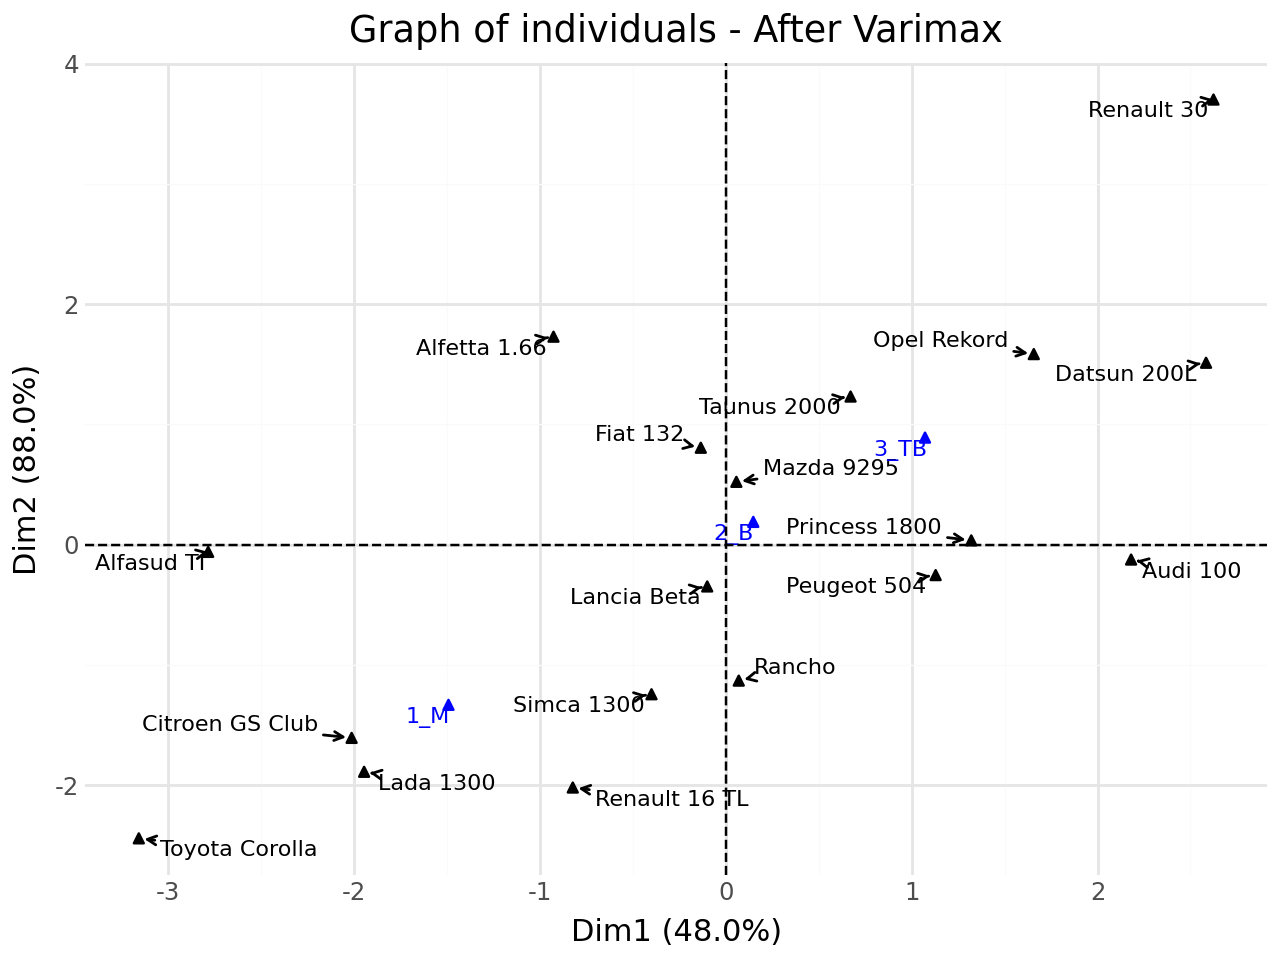

None


In [43]:
# graph of individuals after rotation
p = add_scatter(
    p = ggplot(),
    data = ind_rot.coord,
    color="black",
    repel = True
)
# add levels coordinates
p = add_scatter(
    p = p,
    data = levels_sup_rot.coord,
    color="blue",
    repel = True
)
# set axis
p = set_axis(
    p = p,
    obj=clf2,
    title = "Graph of individuals - After Varimax"
)
print(p.show())

### Supplementary levels vtest after rotation

In [44]:
# supplementary levels vtest after rotation
levels_sup_rot.vtest

,Dim1,Dim2
1_M,-2.248742,-2.200153
2_B,0.285971,0.401138
3_TB,1.840900,1.675634


## Summary

In [45]:
# summary
from scientisttools import summary
summary(clf2)

                     Varimax rotation in Principal Component Analysis - Results                     

Importance of components:
      Eigenvalue  Proportion (%)  Cumulative (%)
Dim1      2.8802         48.0040         48.0040
Dim2      2.3967         39.9447         87.9487

Matrix of rotation:
        Dim1    Dim2
Dim1  0.7535  0.6574
Dim2 -0.6574  0.7535

Individuals (the 10 first):
                   Dim1    Dim2
Alfasud TI      -2.7857 -0.0605
Audi 100         2.1805 -0.1242
Simca 1300      -0.4001 -1.2442
Citroen GS Club -2.0136 -1.6069
Fiat 132        -0.1349  0.8054
Lancia Beta     -0.1003 -0.3478
Peugeot 504      1.1288 -0.2535
Renault 16 TL   -0.8237 -2.0197
Renault 30       2.6237  3.7005
Toyota Corolla  -3.1588 -2.4422

Supplementary individuals:
                 Dim1    Dim2
Peugeot 604    3.9696  3.9125
Peugeot 304 S -2.4939 -0.5065

Continuous:
         Dim1    Dim2
CYL    0.5977  0.6739
PUISS  0.4154  0.8729
LONG   0.9182  0.2954
LARG   0.8844  0.2238
POIDS  0.8297  0.42